In [1]:
import math
import random
import json
import re
import torch
import torch.nn as nn
import torch.nn.functional as F

In [2]:
random.seed(42) # Let there be order among chaos
torch.manual_seed(42)
device = torch.device('cuda')

In [4]:
# Let there be an input dataset `docs`: list[str] of documents (e.g. a dataset of names)
docs = [l.strip() for l in open('data.txt', 'r', encoding='utf-8').read().strip().split('\n') if l.strip()] # list[str] of documents
random.shuffle(docs)
val_size = int(0.05 * len(docs))
val_docs = docs[:val_size]
docs = docs[val_size:]
print(f"train docs: {len(docs)}, val docs: {len(val_docs)}")

train docs: 65520, val docs: 3448


In [5]:
# Let there be a Tokenizer to translate strings to discrete symbols and back
with open('token_id.json', 'r', encoding='utf-8') as file:
    token_ids = json.load(file)
token_ids_map = {tok: i for i, tok in enumerate(token_ids)}
vocab_size = len(token_ids)
print(f"vocab size: {vocab_size}")

vocab size: 3005


In [6]:
n_embd = 64     # embedding dimension
n_head = 4      # number of attention heads
n_layer = 4     # number of layers
block_size = 96 # maximum sequence length
head_dim = n_embd // n_head # dimension of each head

In [7]:
def rmsnorm(x):
    return x * (x.pow(2).mean(-1, keepdim=True) + 1e-5).rsqrt()

In [8]:
class TransformerLayer(nn.Module):
    def __init__(self):
        super().__init__()
        self.attn_wq = nn.Linear(n_embd, n_embd, bias=False)
        self.attn_wk = nn.Linear(n_embd, n_embd, bias=False)
        self.attn_wv = nn.Linear(n_embd, n_embd, bias=False)
        self.attn_wo = nn.Linear(n_embd, n_embd, bias=False)
        self.mlp_fc1 = nn.Linear(n_embd, 4 * n_embd, bias=False)
        self.mlp_fc2 = nn.Linear(4 * n_embd, n_embd, bias=False)

    def forward(self, x):
        B, T, _ = x.shape

        # 1) Multi-head attention block
        x_residual = x
        x = rmsnorm(x)
        q = self.attn_wq(x).view(B, T, n_head, head_dim).transpose(1, 2)
        k = self.attn_wk(x).view(B, T, n_head, head_dim).transpose(1, 2)
        v = self.attn_wv(x).view(B, T, n_head, head_dim).transpose(1, 2)

        x_attn = F.scaled_dot_product_attention(q, k, v, is_causal=True)
        x_attn = x_attn.transpose(1, 2).contiguous().view(B, T, n_embd)
        x = self.attn_wo(x_attn) + x_residual

        # 2) MLP block
        x_residual = x
        x = rmsnorm(x)
        x = F.relu(self.mlp_fc1(x))
        x = self.mlp_fc2(x)
        x = x + x_residual
        return x

    def forward_step(self, x, keys, values):

        # 1) Multi-head attention block
        x_residual = x
        x = rmsnorm(x)
        q = self.attn_wq(x)
        k = self.attn_wk(x)
        v = self.attn_wv(x)
        keys.append(k)
        values.append(v)
        x_attn = []
        for h in range(n_head):
            hs = slice(h * head_dim, (h + 1) * head_dim)
            q_h = q[hs]
            k_h = torch.stack([ki[hs] for ki in keys])
            v_h = torch.stack([vi[hs] for vi in values])
            attn_logits = (k_h @ q_h) / math.sqrt(head_dim)
            attn_weights = torch.softmax(attn_logits, dim=0)
            head_out = (v_h * attn_weights.unsqueeze(1)).sum(0)
            x_attn.append(head_out)
        x = self.attn_wo(torch.cat(x_attn)) + x_residual

        # 2) MLP block
        x_residual = x
        x = rmsnorm(x)
        x = F.relu(self.mlp_fc1(x))
        x = self.mlp_fc2(x)
        x = x + x_residual
        return x

In [9]:
class GPT(nn.Module):
    def __init__(self):
        super().__init__()
        self.wte = nn.Embedding(vocab_size, n_embd)
        self.wpe = nn.Embedding(block_size, n_embd)
        self.layers = nn.ModuleList([TransformerLayer() for _ in range(n_layer)])
        self.lm_head = nn.Linear(n_embd, vocab_size, bias=False)
        self.lm_head.weight = self.wte.weight
        nn.init.normal_(self.wte.weight, std=0.08)
        nn.init.normal_(self.wpe.weight, std=0.08)

    def forward(self, token_ids_batch):
        B, T = token_ids_batch.shape
        pos = torch.arange(T, device=token_ids_batch.device)

        tok_emb = self.wte(token_ids_batch)
        pos_emb = self.wpe(pos)
        x = tok_emb + pos_emb
        x = rmsnorm(x)

        for layer in self.layers:
            x = layer(x)
        x = rmsnorm(x)
        return self.lm_head(x)

    def forward_step(self, token_id, pos_id, keys, values):
        tok_emb = self.wte.weight[token_id]
        pos_emb = self.wpe.weight[pos_id]
        x = tok_emb + pos_emb
        x = rmsnorm(x)

        for li, layer in enumerate(self.layers):
            x = layer.forward_step(x, keys[li], values[li])
        x = rmsnorm(x)
        return self.lm_head(x)

In [10]:
model = GPT().to(device)
print(f"num params: {sum(p.numel() for p in set(model.parameters()))}")

num params: 395072


In [11]:
# Let there be Adam, the blessed optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01, betas=(0.90, 0.99))

In [12]:
def collate(batch_docs, block_size=block_size):
    pattern = r'<SEP>|<UNK>|.'
    PAD = token_ids_map['<EOS>']  # reuse EOS as pad id

    input_batch, target_batch = [], []
    for doc in batch_docs:
        doc_tokens = re.findall(pattern, doc)
        body_starts = doc_tokens.index('<SEP>')
        tokens = [token_ids_map['<BOS>']] + [token_ids_map[t] for t in doc_tokens] + [token_ids_map['<EOS>']]

        seq_in = tokens[:-1]
        seq_out = tokens[1:]

        # mask loss on title + <SEP>
        seq_out = [
            tok if i >= body_starts + 1 else -100
            for i, tok in enumerate(seq_out)
        ]

        pad_len = block_size - len(seq_in)
        seq_in = seq_in + [PAD] * pad_len
        seq_out = seq_out + [-100] * pad_len

        input_batch.append(seq_in)
        target_batch.append(seq_out)

    return torch.tensor(input_batch, device=device), torch.tensor(target_batch, device=device)

In [13]:
@torch.no_grad()
def eval_val_loss(n_batches=5):
    model.eval()
    total_loss = 0.0
    for _ in range(n_batches):
        batch_docs = random.sample(val_docs, min(batch_size, len(val_docs)))
        input_ids, targets = collate(batch_docs)
        logits = model(input_ids)
        loss = F.cross_entropy(logits.view(-1, vocab_size), targets.view(-1), ignore_index=-100)
        total_loss += loss.item()
    model.train()
    return total_loss / n_batches

In [14]:
# Repeat in sequence
num_steps = 50000 # number of training steps
batch_size = 64
losses = []

best_val_loss = float('inf')
val_losses = []

for step in range(num_steps):
    batch_docs = [docs[i] for i in random.sample(range(len(docs)), batch_size)]
    input_ids, targets = collate(batch_docs)
    logits = model(input_ids)
    loss = F.cross_entropy(logits.view(-1, vocab_size), targets.view(-1), ignore_index=-100)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

    lr_t = 0.001 * (1 - step / num_steps)
    for pg in optimizer.param_groups:
        pg['lr'] = lr_t

    if (step % 1000 == 0):
        val_loss = eval_val_loss()
        val_losses.append(val_loss)
        print(f"step {step+1:4d} / {num_steps:4d} \t loss {loss.item():.4f} \t val {val_loss:.4f}")

        if (val_loss < best_val_loss):
            best_val_loss = val_loss
            torch.save(model.state_dict(), 'best_model.pt')             # save the model

step    1 / 50000 	 loss 8.1896 	 val 8.1381
step 1001 / 50000 	 loss 6.2367 	 val 6.3367
step 2001 / 50000 	 loss 5.8033 	 val 5.9163
step 3001 / 50000 	 loss 5.4506 	 val 5.5503
step 4001 / 50000 	 loss 5.3110 	 val 5.3645
step 5001 / 50000 	 loss 5.1367 	 val 5.2763
step 6001 / 50000 	 loss 5.2116 	 val 5.2479
step 7001 / 50000 	 loss 5.1802 	 val 5.1760
step 8001 / 50000 	 loss 5.1645 	 val 5.1886
step 9001 / 50000 	 loss 5.0189 	 val 5.0979
step 10001 / 50000 	 loss 5.0035 	 val 5.1410
step 11001 / 50000 	 loss 4.9724 	 val 5.0630
step 12001 / 50000 	 loss 4.8704 	 val 5.0826
step 13001 / 50000 	 loss 4.9165 	 val 5.0613
step 14001 / 50000 	 loss 4.9141 	 val 5.0132
step 15001 / 50000 	 loss 4.7457 	 val 4.9732
step 16001 / 50000 	 loss 4.8577 	 val 4.9569
step 17001 / 50000 	 loss 4.9074 	 val 5.0014
step 18001 / 50000 	 loss 4.8793 	 val 4.9890
step 19001 / 50000 	 loss 4.8493 	 val 4.9876
step 20001 / 50000 	 loss 4.8703 	 val 4.9641
step 21001 / 50000 	 loss 4.8210 	 val 4.891

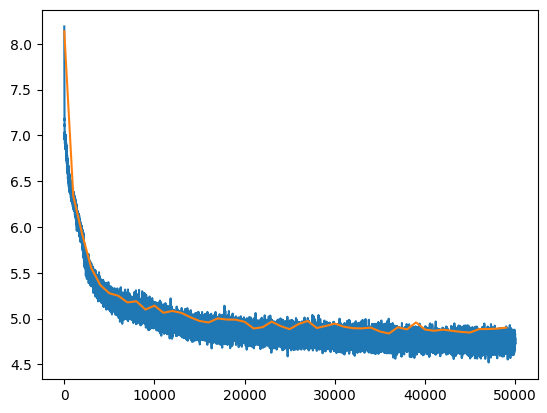

In [19]:
import matplotlib.pyplot as plt
plt.plot(list(range(0, 50000)), losses)
plt.plot(list(range(0, 50000, 1000)), val_losses)
plt.show()

In [20]:
# load best model
model = GPT().to(device)
model.load_state_dict(torch.load('best_model.pt', map_location=device))
model.eval()

GPT(
  (wte): Embedding(3005, 64)
  (wpe): Embedding(96, 64)
  (layers): ModuleList(
    (0-3): 4 x TransformerLayer(
      (attn_wq): Linear(in_features=64, out_features=64, bias=False)
      (attn_wk): Linear(in_features=64, out_features=64, bias=False)
      (attn_wv): Linear(in_features=64, out_features=64, bias=False)
      (attn_wo): Linear(in_features=64, out_features=64, bias=False)
      (mlp_fc1): Linear(in_features=64, out_features=256, bias=False)
      (mlp_fc2): Linear(in_features=256, out_features=64, bias=False)
    )
  )
  (lm_head): Linear(in_features=64, out_features=3005, bias=False)
)

In [21]:
with open('rhyme_table.json', 'r', encoding='utf-8') as file:
    rhyme_table = json.load(file)

with open('tone_table.json', 'r', encoding='utf-8') as file:
    tone_table = json.load(file)

with open('templates.json', 'r', encoding='utf-8') as file:
    templates = json.load(file)

rhyme_dict = {}
for character, rhyme_group in rhyme_table.items():
    rhyme_dict.setdefault(rhyme_group, []).append(character)

tone_dict = {}
for character, tone in tone_table.items():
    tone_dict.setdefault(tone, []).append(character)

In [22]:
def apply_constraints(logits, tone, rhyme_required, rhyme_group, prev_rhymes):
    mask = torch.zeros_like(logits)

    # check tone
    if tone == "平":
        ze_chars = tone_dict['仄']
        ze_token_ids = [token_ids_map[char] for char in ze_chars]
        mask[ze_token_ids] = float('-inf')
    elif tone == '仄':
        ping_chars = tone_dict['平']
        ping_token_ids = [token_ids_map[char] for char in ping_chars]
        mask[ping_token_ids] = float('-inf')

    # check rhyme
    if rhyme_required:
        non_rhyme_chars = [
            character for rhyme_groups, characters in rhyme_dict.items()
            if rhyme_groups != rhyme_group
            for character in characters
        ]
        non_rhyme_token_ids = [token_ids_map[char] for char in non_rhyme_chars]
        mask[non_rhyme_token_ids] = float('-inf')

        # cannot rhyme on the same character
        if len(prev_rhymes) > 0:
            prev_rhyme_token_ids = [token_ids_map[char] for char in prev_rhymes]
            mask[prev_rhyme_token_ids] = float('-inf')

    return mask

In [25]:
title = "送别"
prefix = [token_ids_map['<BOS>']] + [token_ids_map[c] for c in title] + [token_ids_map['<SEP>']]

temperature = 0.6 # in (0, 1], control the "creativity" of generated text, low to high
print("\n--- inference (new, hallucinated poems) ---")

with torch.no_grad():
    for sample_idx in range(5):
        keys, values = [[] for _ in range(n_layer)], [[] for _ in range(n_layer)]

        # Prime KV cache with title — run forward but don't sample
        for pos_id, token_id in enumerate(prefix):
            logits = model.forward_step(token_id, pos_id, keys, values)

        print("Sample %d:" % (sample_idx + 1))
        sample = []
        rhyme_group = None
        rhyme_required = False
        prev_rhymes = []
        generated_ids = []
        repetition_penalty = 1.3

        # random template
        template_num = random.randint(1, 4)
        template = templates["template" + str(template_num)]

        for pos_id in range(block_size - len(prefix)):

            # ban unknown characters and invalid tokens
            logits[token_ids_map['<UNK>']] = float('-inf')
            logits[token_ids_map['<BOS>']] = float('-inf')
            logits[token_ids_map['<SEP>']] = float('-inf')

            # repetition penalty
            if generated_ids:
                for tid in generated_ids:
                    if logits[tid] > 0:
                        logits[tid] /= repetition_penalty
                    else:
                        logits[tid] *= repetition_penalty

            # check if rhyme required
            if (pos_id % 14 == 13 and rhyme_group != None):
                rhyme_required = True
            else:
                rhyme_required = False

            mask = apply_constraints(logits, template[pos_id % 56], rhyme_required, rhyme_group, prev_rhymes)
            probs = torch.softmax((logits + mask) / temperature, dim=0)
            token_id = torch.multinomial(probs, 1).item()

            # check if poem ends
            if token_id == token_ids_map['<EOS>']:
                break

            character = token_ids[token_id]
            sample.append(character)
            print(character, end="")

            if token_id not in generated_ids:
                generated_ids.append(token_id)

            if (rhyme_required):
                prev_rhymes.append(character)

            # confirm rhyme group if character is the first in poem that rhymes
            if (template_num in [1, 3] and pos_id % 14 == 13) or (template_num in [2, 4] and pos_id % 14 == 6):
                if rhyme_group == None:
                    rhyme_group = rhyme_table[character]
                    prev_rhymes.append(character)

            # add punctuations
            if (pos_id % 14 == 6):
                print("，", end="")
            elif (pos_id % 14 == 13):
                print("。")

            logits = model.forward_step(token_id, pos_id + len(prefix), keys, values)
        print()


--- inference (new, hallucinated poems) ---
Sample 1:
十载江湖万里穷，相逢喜有两人同。
颜生鬓雪凋逾落，如旧年光薄未红。
此日往来殊不解，使君怀古自能雄。
庞公早晚还归去，今看前时亦独东。

Sample 2:
一骑归来笑语还，红旗夜出柳阴边。
鴈声流水人家好，雁影寒林树里悬。
客枕新诗偏有味，醉哦残酒自无弦。
溪山不与君恩在，明日东风慰寂然。

Sample 3:
东风吹雨几何由，共说连宵旧日留。
万里如今多少子，一声不复更佳侯。
归怀淮北春无色，到底吴边酒未愁。
明月凄凉无梦断，君时相望忆江头。

Sample 4:
摩挲诗卷在天地，一片青山与世违。
天下相逢元亮夜，鬓边不见白云归。
人心不信天涯动，眼底无情雨脚微。
客路悠然无此事，君才跨马去何依。

Sample 5:
行时贤相过归处，消得家山一笑来。
吟罢萧条无事尽，醉来樽俎有情催。
我非有客难同饮，我亦无人未足哀。
今日不须寻旧隐，早知花色到城台。

